# Colab

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/CS-4452 Computer Vision - Code')

Mounted at /content/drive


# Import

In [2]:
from dotenv import load_dotenv
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.spatial.distance import directed_hausdorff
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [3]:
load_dotenv()
path = os.getenv("DATA_PATH")
print(path)

/content/drive/MyDrive/CS-4452 Computer Vision - Code/2_processed_dataset_with_data_augmentation


In [4]:
test_path = os.path.join(path, "test")
test_img_path = os.path.join(test_path, "images")
test_mask_path = os.path.join(test_path, "masks")
print("test path:", test_path)
print("test images path:", test_img_path)
print("test masks path:", test_mask_path)

test path: /content/drive/MyDrive/CS-4452 Computer Vision - Code/2_processed_dataset_with_data_augmentation/test
test images path: /content/drive/MyDrive/CS-4452 Computer Vision - Code/2_processed_dataset_with_data_augmentation/test/images
test masks path: /content/drive/MyDrive/CS-4452 Computer Vision - Code/2_processed_dataset_with_data_augmentation/test/masks


In [5]:
model_path = "./model"
history_path = "./history.json"
print("model_path:", os.path.abspath(model_path))
print("model_path:", os.path.abspath(history_path))

model_path: /content/drive/MyDrive/CS-4452 Computer Vision - Code/model
model_path: /content/drive/MyDrive/CS-4452 Computer Vision - Code/history.json


# Data

In [6]:
def load_images(dir):
  images = []
  filenames = sorted(os.listdir(dir))

  for name in tqdm(filenames, desc="Loading Images..."):
    path = os.path.join(dir, name)
    img = Image.open(path)
    img = np.array(img, dtype=np.float32) / 255.0
    img = np.expand_dims(img, axis=0)
    images.append(img)

  images = np.array(images)
  return torch.tensor(images)

In [7]:
def load_masks(dir):
  masks = []
  filenames = sorted(os.listdir(dir))

  for name in tqdm(filenames, desc="Loading Masks..."):
    path = os.path.join(dir, name)
    mask = Image.open(path)
    mask = np.array(mask, dtype=np.float32)
    mask = (mask > 0).astype(np.float32)
    mask = np.expand_dims(mask, axis=0)
    masks.append(mask)

  masks = np.array(masks)
  return torch.tensor(masks)

In [8]:
test_img_data = load_images(test_img_path)
test_mask_data = load_masks(test_mask_path)
print("\n")
print(test_img_data.shape)
print(test_mask_data.shape)

Loading Masks...: 100%|██████████| 565/565 [00:07<00:00, 71.27it/s] 




torch.Size([565, 1, 128, 128])
torch.Size([565, 1, 128, 128])


# Model

In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(UNet, self).__init__()
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv3 = DoubleConv(128, 64)

        self.outc = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(F.max_pool2d(x1, 2))
        x3 = self.down3(F.max_pool2d(x2, 2))
        x4 = self.down4(F.max_pool2d(x3, 2))

        x = self.up1(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.conv1(x)
        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)
        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv3(x)
        return self.outc(x)

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super(BCEDiceLoss, self).__init__()
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, inputs, targets, smooth=1e-5):
        bce_loss = self.bce(inputs, targets)
        inputs = torch.sigmoid(inputs).view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss

def calculate_metrics(preds, targets):
    preds = torch.sigmoid(preds) > 0.5
    targets = targets > 0.5
    preds = preds.cpu().numpy()
    targets = targets.cpu().numpy()

    batch_size = preds.shape[0]
    acc_sum = 0
    dice_sum = 0
    iou_sum = 0
    hd_sum = 0

    for i in range(batch_size):
        p = preds[i, 0]
        t = targets[i, 0]
        acc_sum += (p == t).mean()
        intersection = np.logical_and(p, t).sum()
        union = np.logical_or(p, t).sum()

        if t.sum() == 0 and p.sum() == 0:
            dice_sum += 1.0
            iou_sum += 1.0
        else:
            dice_sum += 2. * intersection / (p.sum() + t.sum() + 1e-6)
            iou_sum += intersection / (union + 1e-6)

        p_coords = np.argwhere(p)
        t_coords = np.argwhere(t)
        if len(p_coords) == 0 and len(t_coords) == 0:
            hd_sum += 0.0
        elif len(p_coords) == 0 or len(t_coords) == 0:
            hd_sum += np.sqrt(p.shape[0]**2 + p.shape[1]**2)
        else:
            hd_sum += max(directed_hausdorff(p_coords, t_coords)[0], directed_hausdorff(t_coords, p_coords)[0])

    return acc_sum, dice_sum, iou_sum, hd_sum


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
model = UNet(in_channels=1, out_channels=1).to(device)
model_file = os.path.join(model_path, "best_unet.pth")
if os.path.exists(model_file):
    model.load_state_dict(torch.load(model_file, map_location=device))
    print("Model loaded successfully from", model_file)
else:
    print(f"Model file not found at {model_file}.")
model.eval()

if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)
    print("History loaded successfully from", history_path)
else:
    print(f"History file not found at {history_path}.")
    history = None


Model loaded successfully from ./model/best_unet.pth
History loaded successfully from ./history.json


# Prediction Results

In [12]:
BATCH_SIZE = 16
BCE_WEIGHT = 0.5
test_dataset = TensorDataset(test_img_data, test_mask_data)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

criterion = BCEDiceLoss(bce_weight=BCE_WEIGHT)

test_loss = 0.0
test_acc = 0.0
test_dice = 0.0
test_iou = 0.0
test_hd = 0.0

print("Evaluating...")
model.eval()
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)

        a, d, iou, hd = calculate_metrics(outputs, labels)
        test_acc += a
        test_dice += d
        test_iou += iou
        test_hd += hd

dataset_len = len(test_dataset)
test_loss /= dataset_len
test_acc /= dataset_len
test_dice /= dataset_len
test_iou /= dataset_len
test_hd /= dataset_len

print("\n")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Dice: {test_dice:.4f}")
print(f"Test IoU: {test_iou:.4f}")
print(f"Test Hausdorff: {test_hd:.4f}")


Evaluating...


Testing: 100%|██████████| 36/36 [00:03<00:00, 10.92it/s]



Test Loss: 0.3703
Test Accuracy: 0.9891
Test Dice: 0.6939
Test IoU: 0.6577
Test Hausdorff: 39.2116


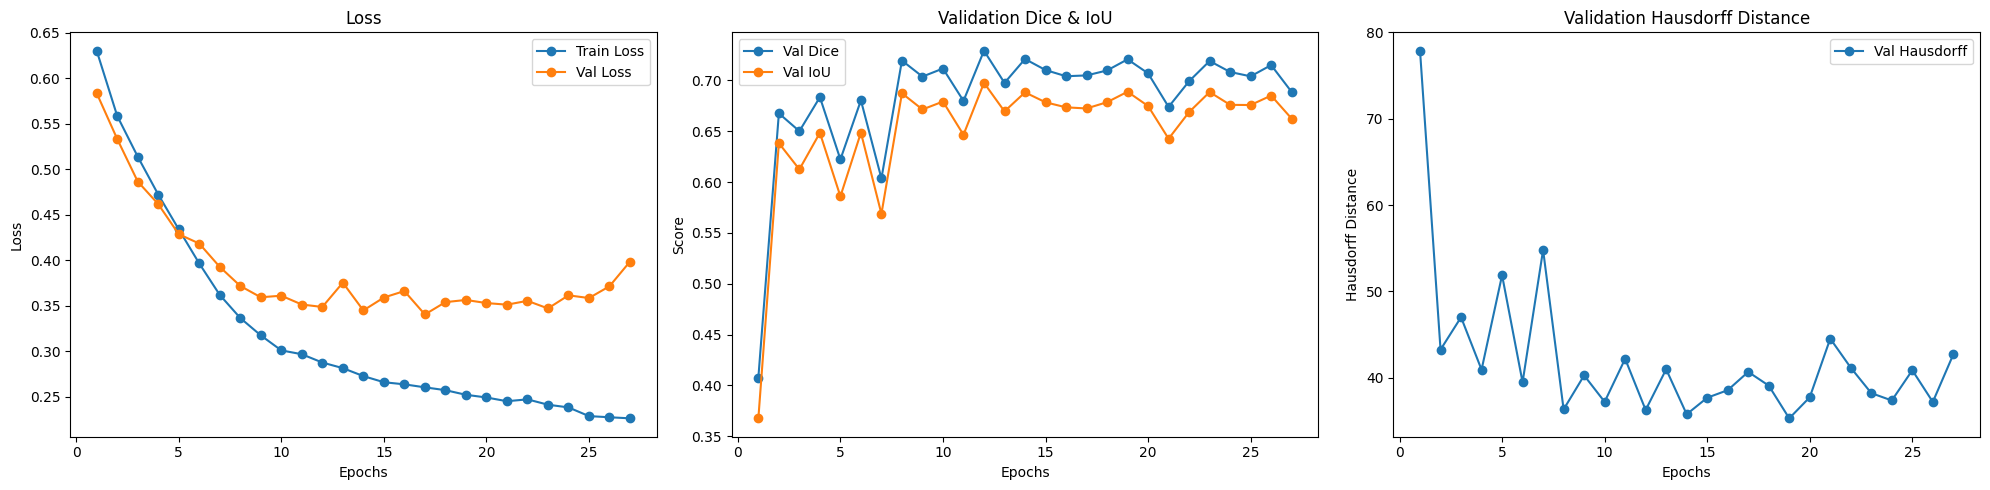

In [30]:
if history is not None:
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(20, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['val_dice'], label='Val Dice', marker='o')
    plt.plot(epochs, history['val_iou'], label='Val IoU', marker='o')
    plt.title('Validation Dice & IoU')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['val_hausdorff'], label='Val Hausdorff', marker='o')
    plt.title('Validation Hausdorff Distance')
    plt.xlabel('Epochs')
    plt.ylabel('Hausdorff Distance')
    plt.legend()

    plt.tight_layout()
    plt.show()


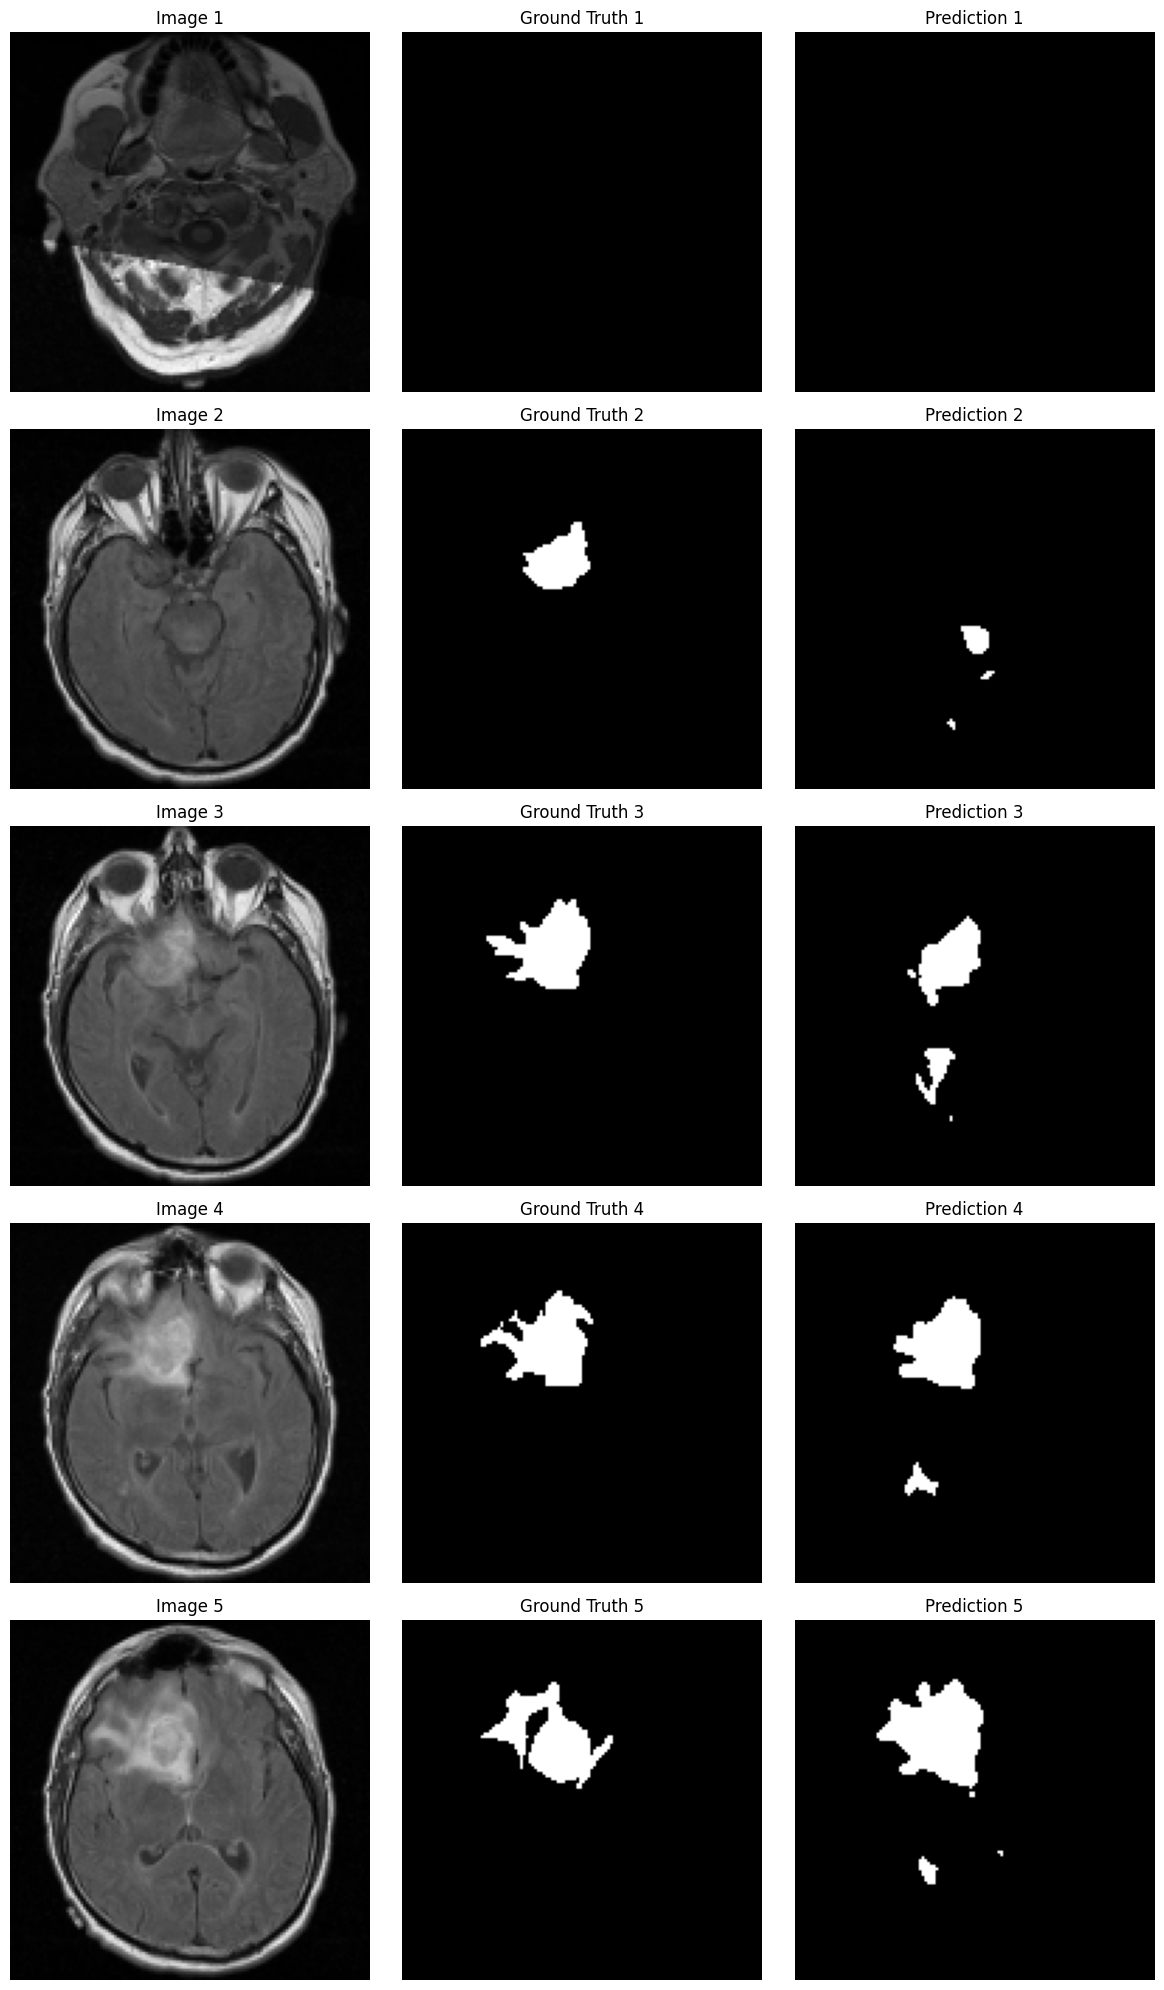

In [14]:
num_images = 5
model.eval()

plt.figure(figsize=(12, 4 * num_images))

with torch.no_grad():
    for i in range(min(num_images, len(test_img_data))):
        img_tensor = test_img_data[i].unsqueeze(0).to(device)
        mask_tensor = test_mask_data[i].unsqueeze(0).to(device)

        output = model(img_tensor)
        pred = torch.sigmoid(output) > 0.5

        img_plot = img_tensor.cpu().numpy()[0, 0]
        mask_plot = mask_tensor.cpu().numpy()[0, 0]
        pred_plot = pred.cpu().numpy()[0, 0]

        plt.subplot(num_images, 3, i * 3 + 1)
        plt.imshow(img_plot, cmap='gray')
        plt.title(f"Image {i+1}")
        plt.axis('off')

        plt.subplot(num_images, 3, i * 3 + 2)
        plt.imshow(mask_plot, cmap='gray')
        plt.title(f"Ground Truth {i+1}")
        plt.axis('off')

        plt.subplot(num_images, 3, i * 3 + 3)
        plt.imshow(pred_plot, cmap='gray')
        plt.title(f"Prediction {i+1}")
        plt.axis('off')

plt.tight_layout()
plt.show()
